# Eksplorativna analiza podataka

**Problem:** Selekcija algoritma pretrage stabla igre (Rice, 1976).  
**Pitanje:** Može li se iz strukturnih karakteristika stabla predvideti koji algoritam između Alpha-Beta (AB) ili MCTS pronalazi optimalni prvi potez?  
**Skup podataka:** 5016 sintetičkih stabala igre, 136 atributa, 4 klase.

---

## 1. Učitavanje podataka

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from theme import *

In [67]:
from pathlib import Path
Path("../plots/eda").mkdir(parents=True, exist_ok=True)

In [68]:
df = pd.read_csv("../data/trees.csv")
df.head()

,branching_factor,depth,chance_node_density,evaluation_noise,tree_balance,total_nodes,total_leaves,total_internal_nodes,total_chance_nodes,total_max_nodes,...,mcts_iterations,mcts_exploration_constant,mcts_visit_entropy,mcts_vote_margin,mcts_search_time,which_algo,ab_correct,mcts_correct,is_contested,margin_category
0,2,15,0.0,0.435996,0.865497,49263,24632,24631,0,16309,...,500,1.414214,0.673012,0.200,0.041193,Both,1,1,1,low
1,2,15,0.0,0.327626,0.720090,37665,18833,18832,0,12364,...,500,1.414214,0.677578,0.176,0.038508,AB,1,0,0,medium
2,2,15,0.0,0.446219,0.743061,39929,19965,19964,0,13144,...,500,1.414214,0.675370,0.188,0.048956,Both,1,1,1,low
3,2,15,0.0,0.295134,0.762014,44397,22199,22198,0,14615,...,500,1.414214,0.693139,0.004,0.123795,Both,1,1,1,low
4,2,15,0.0,0.284099,0.653208,37617,18809,18808,0,12307,...,500,1.414214,0.692947,0.020,0.034585,AB,1,0,1,low


In [ ]:
print(f"Broj slogova: {len(df)}")
print(f"Broj atributa: {len(df.columns)}")

## 2. Tipovi atributa i nedostajuće vrednosti

In [70]:
df.dtypes.value_counts()

float64    71
int64      63
str         2
Name: count, dtype: int64

In [71]:
df.select_dtypes(exclude="number").columns.tolist()

['which_algo', 'margin_category']

In [72]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 3. Opisna statistika

In [73]:
df.select_dtypes("number").describe().transpose().round(3)

,count,mean,std,min,25%,50%,75%,max
branching_factor,5016.0,7.000,4.500,2.000,3.750,5.500,9.000,16.000
depth,5016.0,6.875,3.516,3.000,4.750,6.000,7.500,15.000
chance_node_density,5016.0,0.500,0.316,0.000,0.200,0.500,0.800,1.000
evaluation_noise,5016.0,0.251,0.145,0.000,0.124,0.251,0.377,0.500
tree_balance,5016.0,0.747,0.145,0.500,0.620,0.748,0.872,1.000
...,...,...,...,...,...,...,...,...
mcts_vote_margin,5016.0,0.160,0.226,0.000,0.018,0.056,0.190,0.980
mcts_search_time,5016.0,0.018,0.010,0.003,0.013,0.016,0.020,0.172
ab_correct,5016.0,0.393,0.488,0.000,0.000,0.000,1.000,1.000
mcts_correct,5016.0,0.406,0.491,0.000,0.000,0.000,1.000,1.000


## 4. Raspodela ciljnih atributa

In [74]:
df["which_algo"].value_counts()

which_algo
Neither    2122
Both       1109
MCTS        925
AB          860
Name: count, dtype: int64

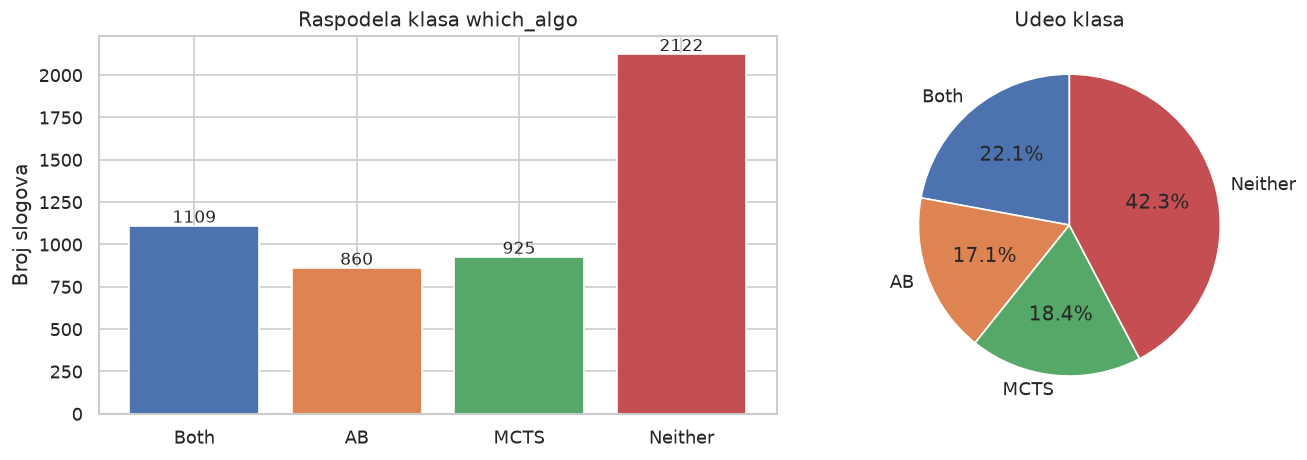

In [75]:
counts = df["which_algo"].value_counts().reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values, color=[CLASS_COLORS[c] for c in counts.index])
axes[0].set_title("Raspodela klasa which_algo")
axes[0].set_ylabel("Broj slogova")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 20, str(v), ha="center", fontsize=10)

axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Udeo klasa")

plt.tight_layout()
plt.savefig("../plots/eda/raspodela_klasa.png", bbox_inches="tight")
plt.show()

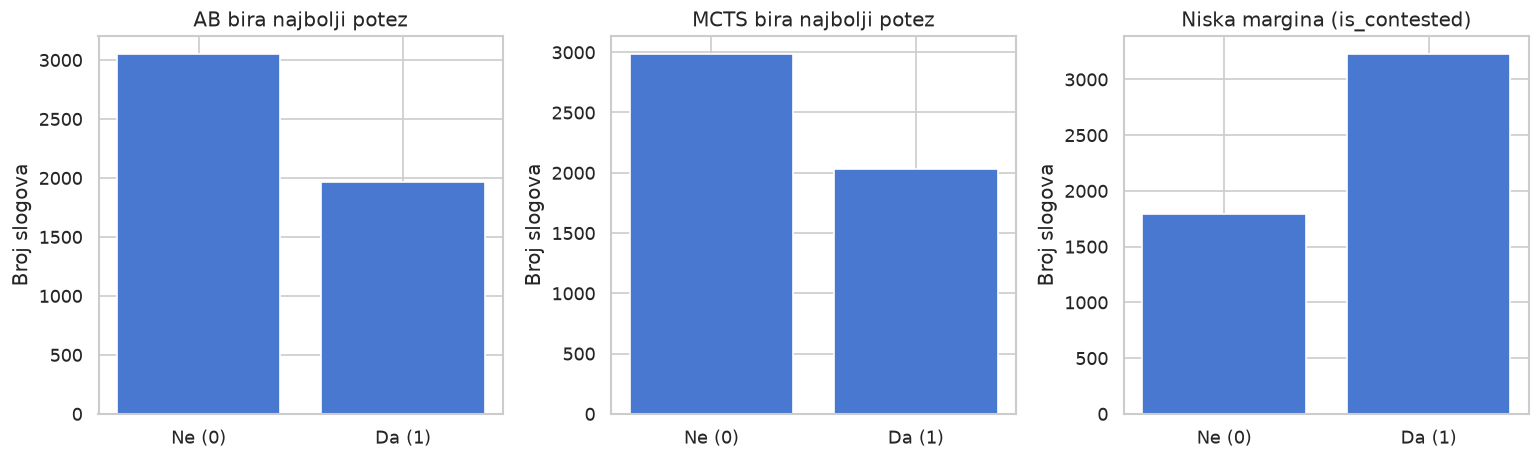

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# is_contested ako je margin < 0.1 tj razlika izmedju dva najbolja poteza je jako mala
binary_cols = ["ab_correct", "mcts_correct", "is_contested"]
titles = ["AB bira najbolji potez", "MCTS bira najbolji potez", "Niska margina (is_contested)"]

for ax, col, title in zip(axes, binary_cols, titles):
    vc = df[col].value_counts().sort_index()
    ax.bar(["Ne (0)", "Da (1)"], vc.values)
    ax.set_title(title)
    ax.set_ylabel("Broj slogova")

plt.tight_layout()
plt.savefig("../plots/eda/binarni_targeti.png", bbox_inches="tight")
plt.show()

## 5. Raspodela parametara stabla

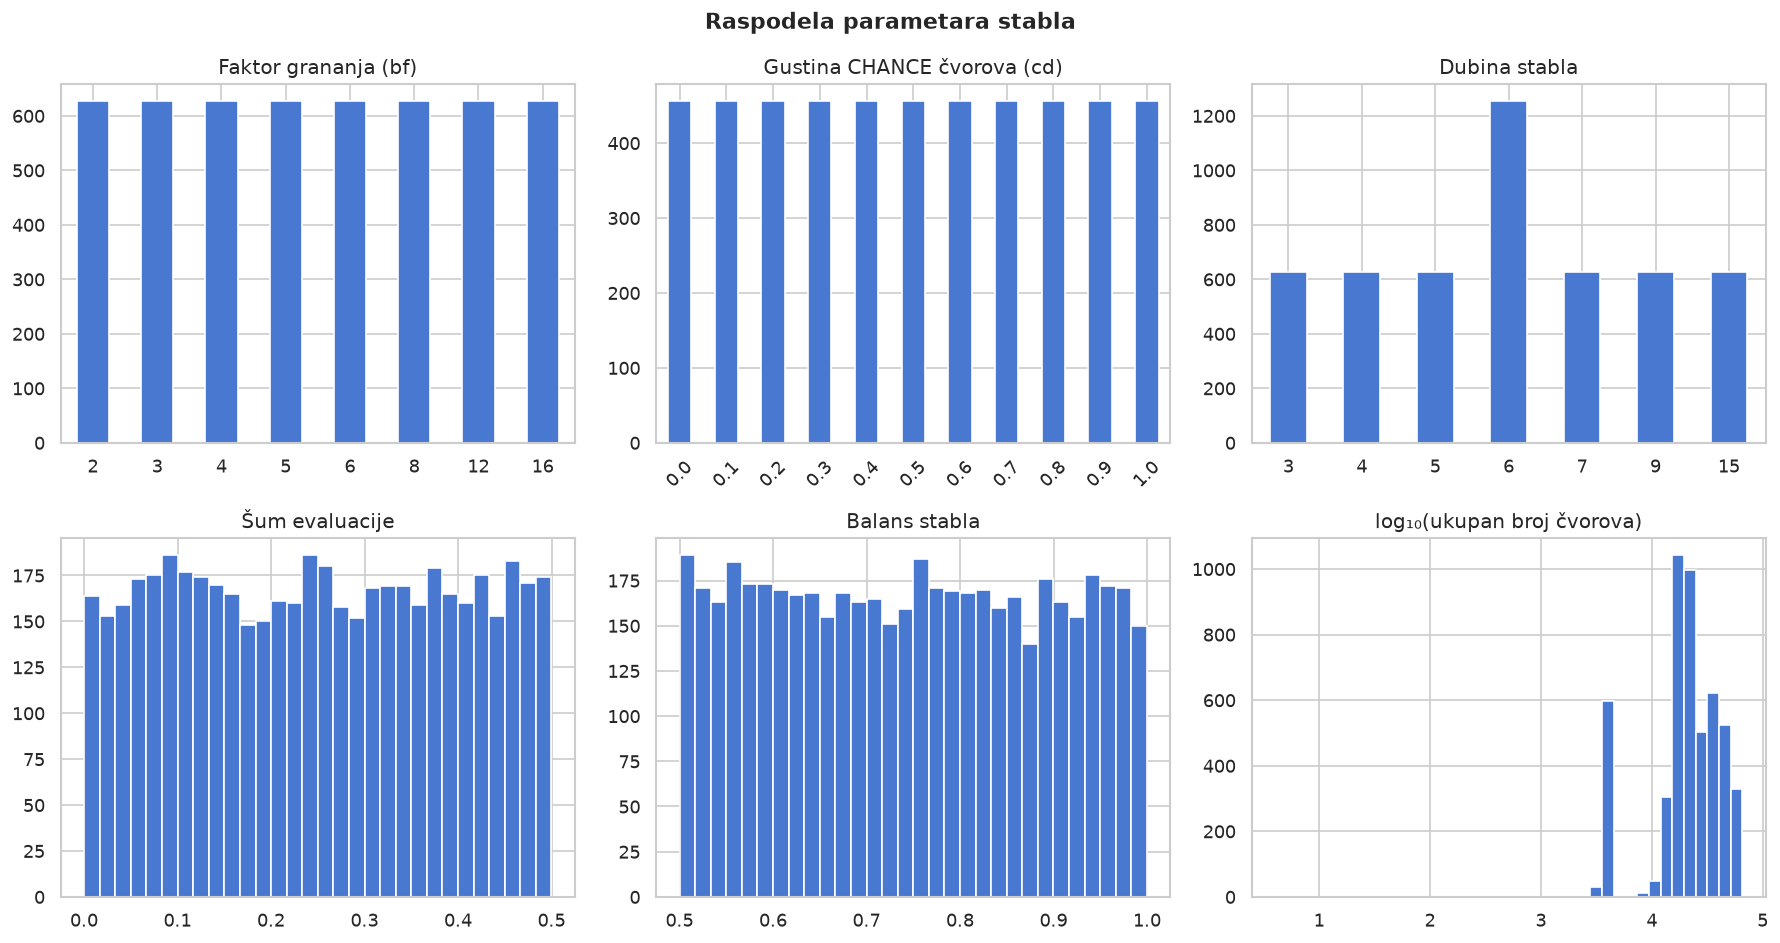

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df["branching_factor"].value_counts().sort_index().plot.bar(ax=axes[0, 0], rot=0)
axes[0, 0].set_title("Faktor grananja (bf)")

df["chance_node_density"].value_counts().sort_index().plot.bar(ax=axes[0, 1], rot=45)
axes[0, 1].set_title("Gustina CHANCE čvorova (cd)")

df["depth"].value_counts().sort_index().plot.bar(ax=axes[0, 2], rot=0)
axes[0, 2].set_title("Dubina stabla")

# evaluation_noise je mali šum dodat vrednostima listovima da se doda jos malo nasumicnosti, nije kljucan parametar
axes[1, 0].hist(df["evaluation_noise"], bins=30) # koristimo hist jer radimo sa neprekidnim vrednostima
axes[1, 0].set_title("Šum evaluacije")

axes[1, 1].hist(df["tree_balance"], bins=30)
axes[1, 1].set_title("Balans stabla")

axes[1, 2].hist(np.log10(df["total_nodes"] + 1), bins=40)
axes[1, 2].set_title("log₁₀(ukupan broj čvorova)")

for ax in axes.flat:
    ax.set_xlabel("")

plt.suptitle("Raspodela parametara stabla", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/raspodela_parametara.png", bbox_inches="tight")
plt.show()

## 6. Atributi po klasama

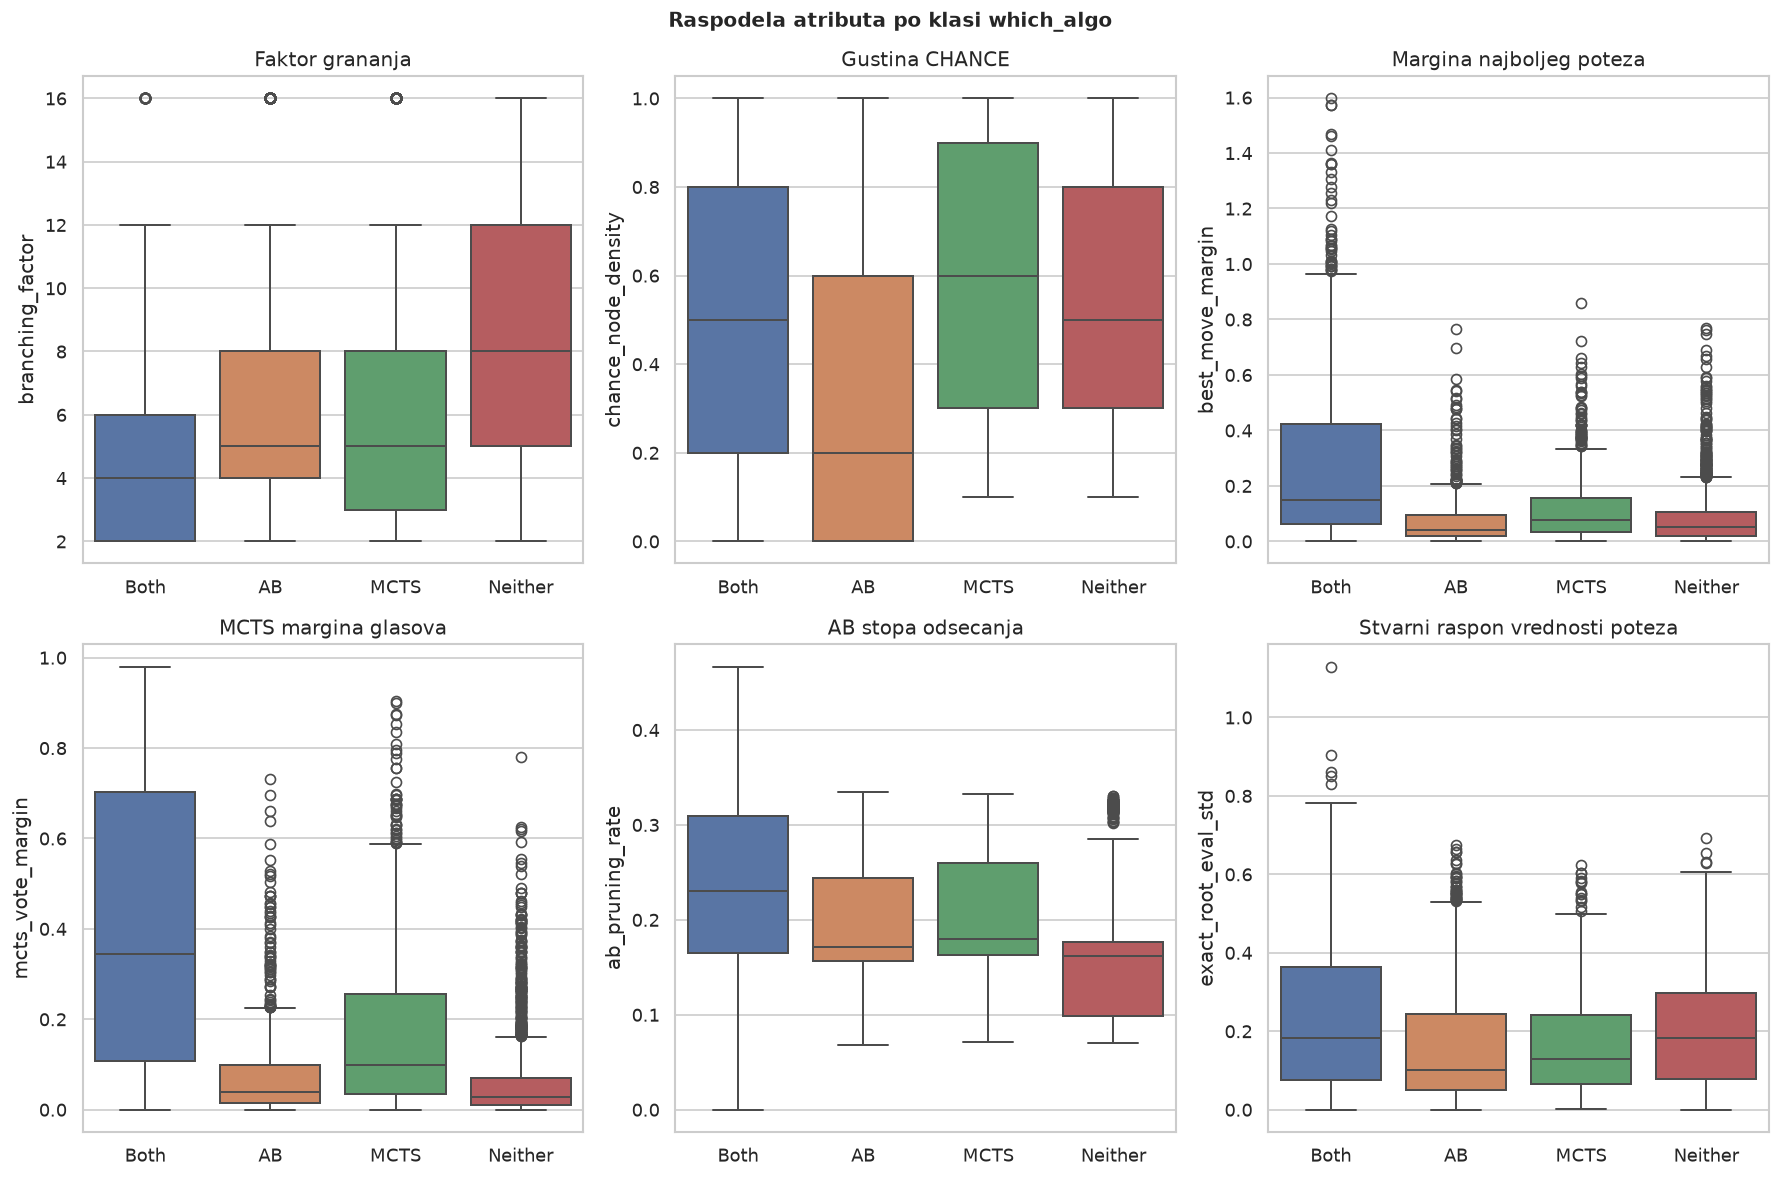

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = [
    "branching_factor", "chance_node_density", "best_move_margin",
    "mcts_vote_margin", "ab_pruning_rate", "exact_root_eval_std"
]
titles = [
    "Faktor grananja", "Gustina CHANCE", "Margina najboljeg poteza",
    "MCTS margina glasova", "AB stopa odsecanja", "Stvarni raspon vrednosti poteza"
]

for ax, col, title in zip(axes.flat, cols, titles):
    sns.boxplot(
        data=df, x="which_algo", y=col,
        hue="which_algo", order=CLASS_ORDER, palette=CLASS_COLORS,
        legend=False, ax=ax, linewidth=1.2
    )
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Raspodela atributa po klasi which_algo", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/boxplots_atributi.png", bbox_inches="tight")
plt.show()

## 7. Analiza autlajera

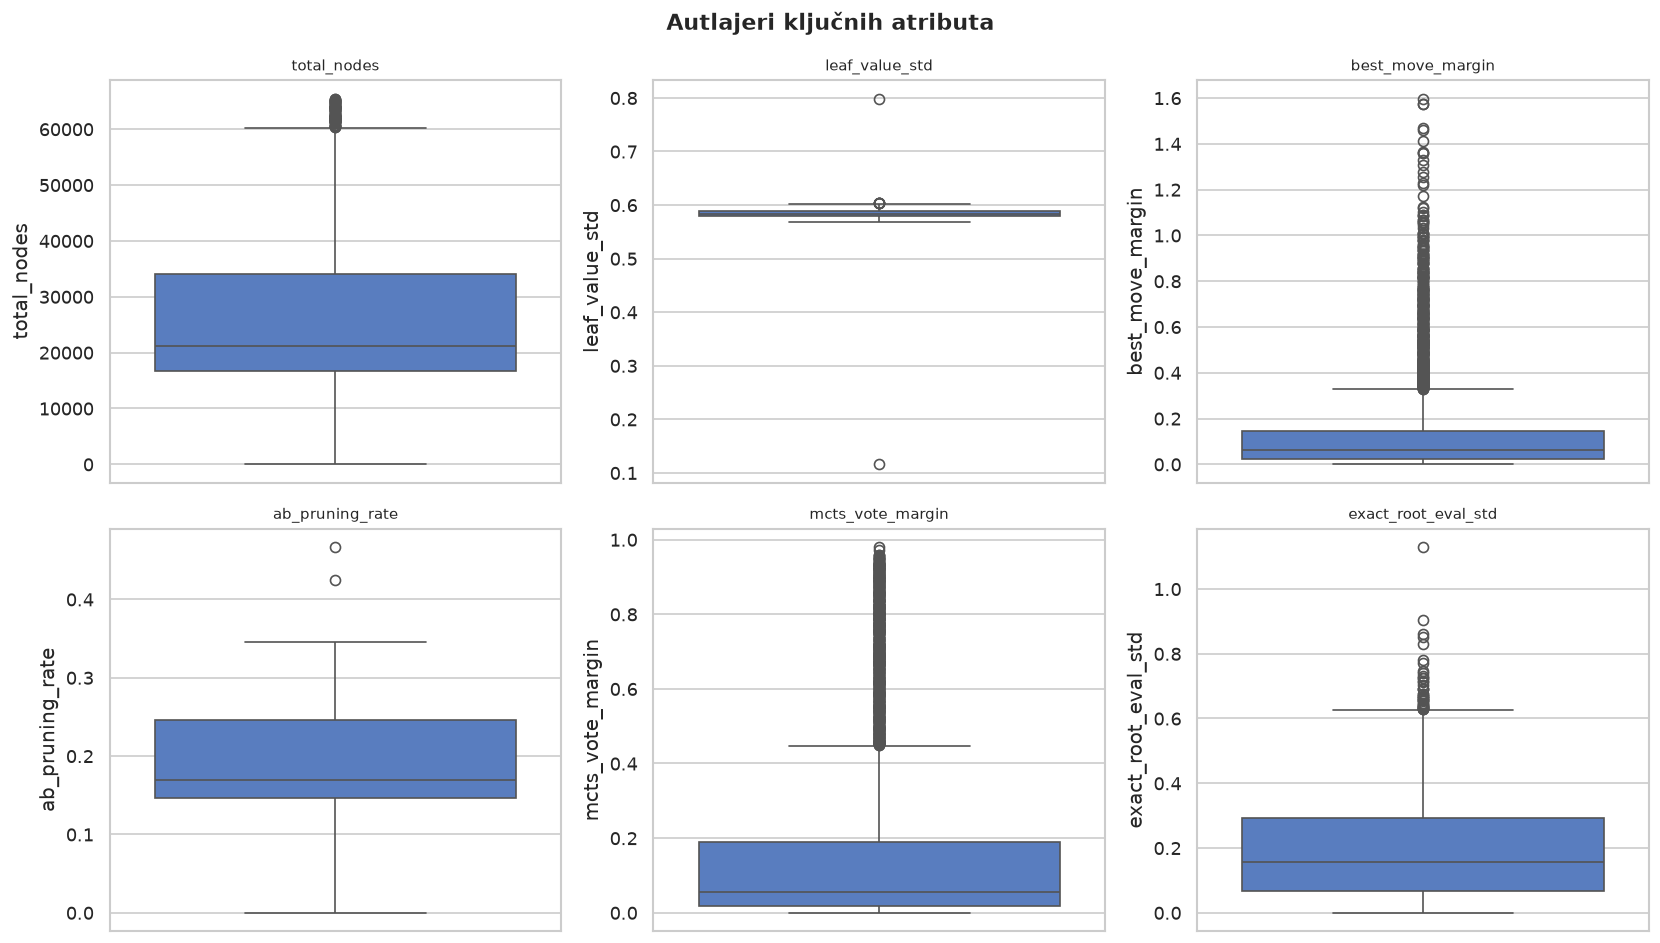

In [79]:
outlier_cols = [
    "total_nodes", "leaf_value_std", "best_move_margin",
    "ab_pruning_rate", "mcts_vote_margin", "exact_root_eval_std"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

plt.suptitle("Autlajeri ključnih atributa", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/autlajeri_iqr.png", bbox_inches="tight")
plt.show()

## 8. Korelaciona analiza

Koji atributi su najpovezaniji sa tačnošću svakog algoritma?

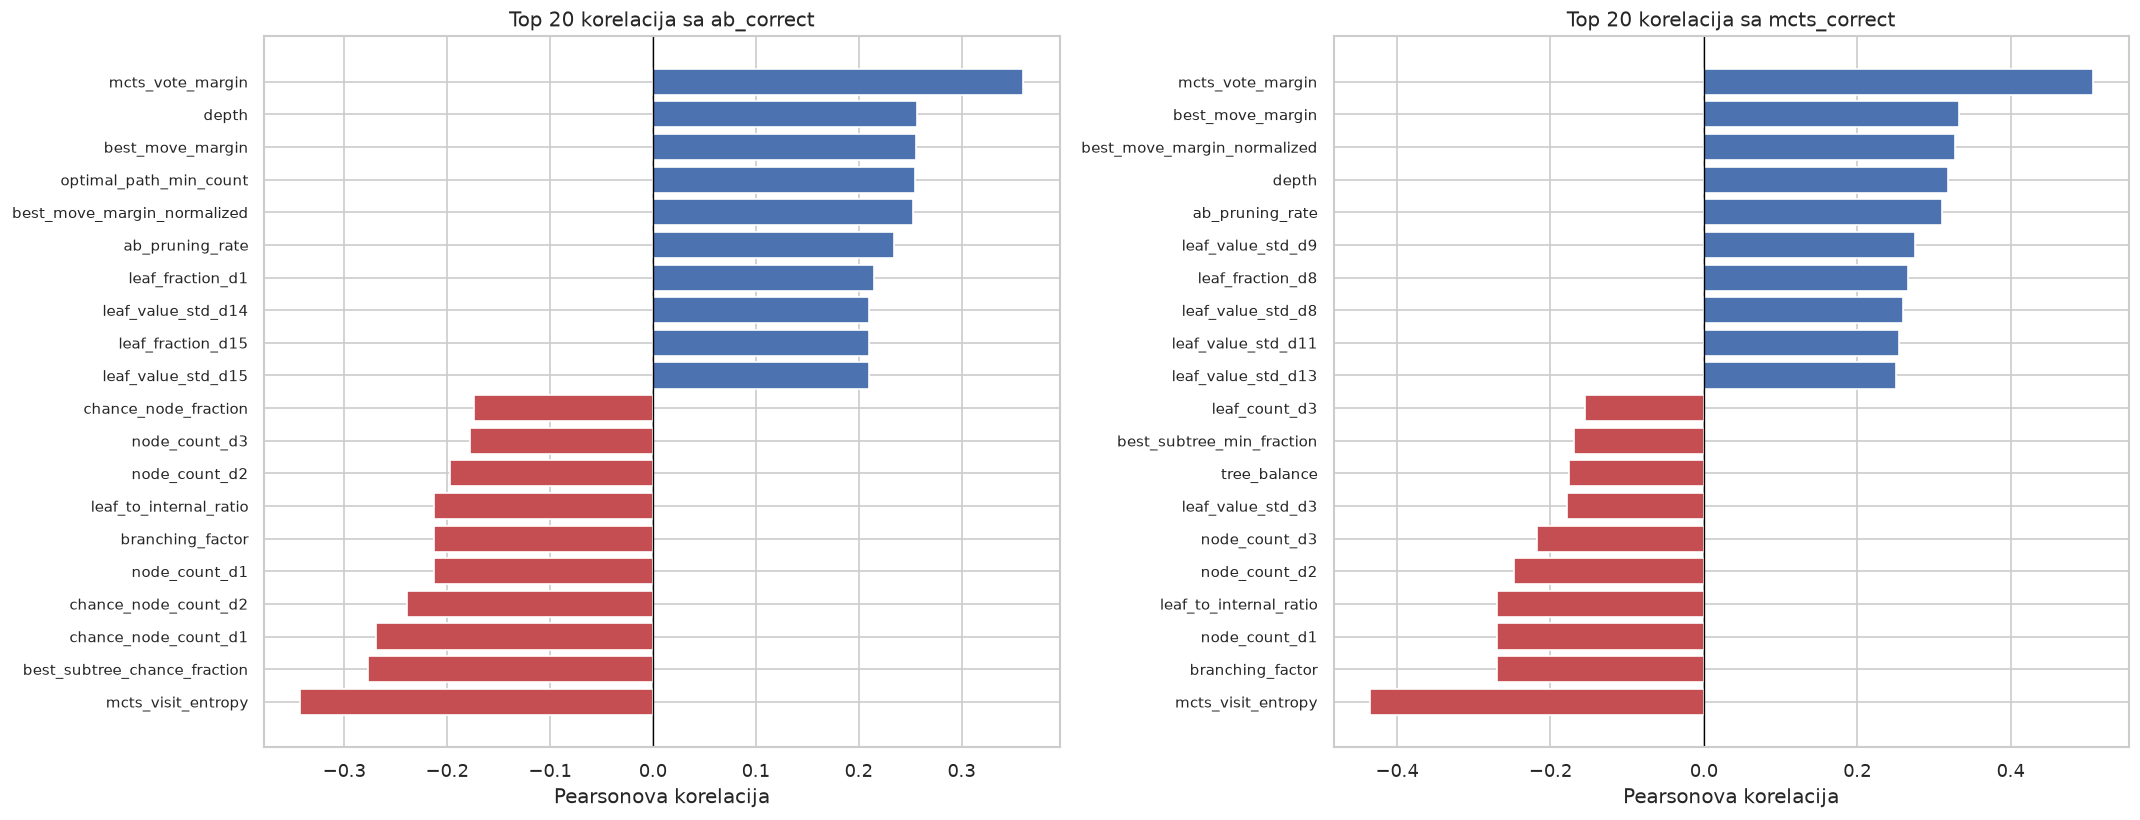

In [80]:
TARGETS_SKIP = {"ab_correct", "mcts_correct", "is_contested",
                "mcts_iterations", "mcts_exploration_constant"}

feat_num = [c for c in df.select_dtypes("number").columns
            if c not in TARGETS_SKIP and df[c].std() > 0]

targets = ["ab_correct", "mcts_correct"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, target in zip(axes, targets):
    corr = df[feat_num].corrwith(df[target]).sort_values()
    n = min(10, len(corr) // 2)
    top = pd.concat([corr.head(n), corr.tail(n)])

    ax.barh(range(len(top)), top.values,
            color=[NEG_COLOR if v < 0 else POS_COLOR for v in top.values])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top {2*n} korelacija sa {target}", fontsize=12)
    ax.set_xlabel("Pearsonova korelacija")

plt.tight_layout()
plt.savefig("../plots/eda/korelacija_ab_mcts.png", bbox_inches="tight")
plt.show()

In [ ]:
selected = [
    "branching_factor", "chance_node_density", "depth",
    "total_nodes", "chance_node_fraction", "leaf_value_std", "leaf_value_range",
    "best_move_margin", "best_move_margin_normalized",
    "optimal_path_chance_count",
    "ab_pruning_rate", "ab_root_eval_std",
    "mcts_vote_margin", "exact_root_eval_std",
    "ab_correct", "mcts_correct"
]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    df[selected].corr(), ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".1f", annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    square=True, cbar_kws={"shrink": 0.7}
)
ax.set_title("Korelaciona matrica odabranih atributa", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("../plots/eda/korelaciona_matrica.png", bbox_inches="tight")
plt.show()

## 9. PCA vizualizacija u 2D

PCA na svim numeričkim atributima - da li su klase linearno razdvojive?

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

skip = ["which_algo", "ab_correct", "mcts_correct", "is_contested", "margin_category",
        "mcts_iterations", "mcts_exploration_constant"] # preskacemo i hiperparametre algoritama
X = df.drop(columns=skip).select_dtypes("number")

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

print(f"Broj atributa za PCA: {X.shape[1]}")

Broj atributa za PCA: 129


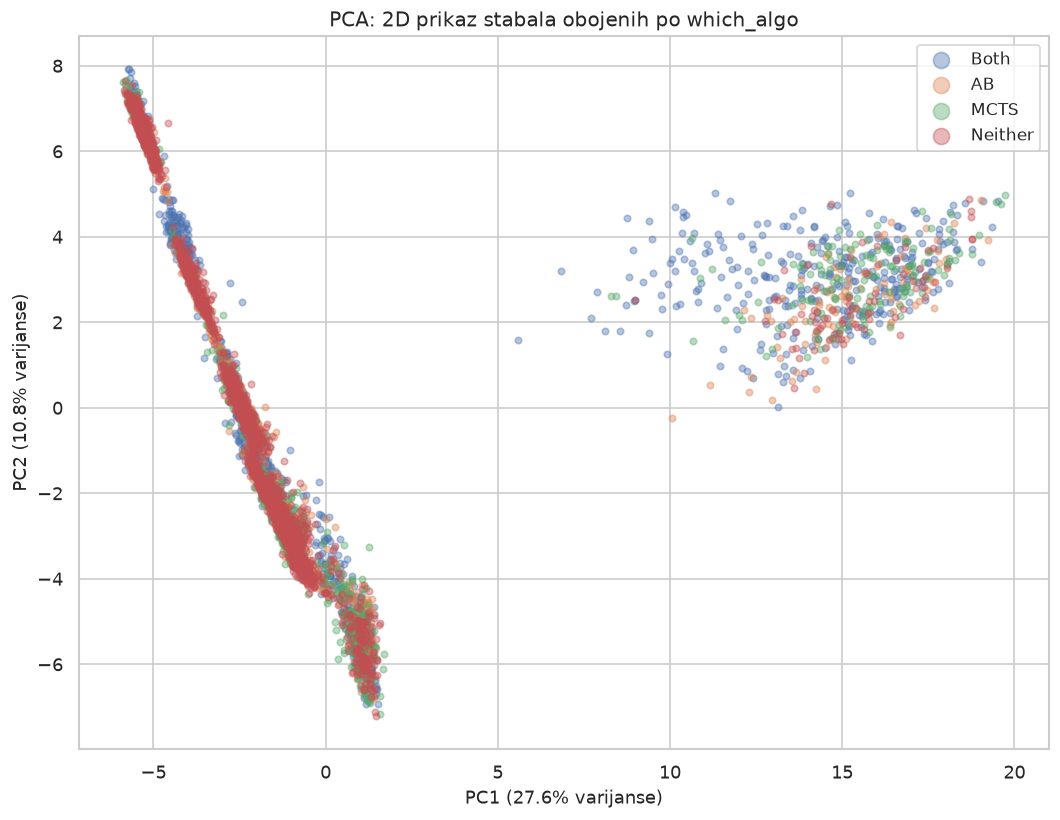

In [83]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in CLASS_ORDER:
    mask = df["which_algo"] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=CLASS_COLORS[cls], label=cls, alpha=0.4, s=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varijanse)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varijanse)", fontsize=11)
ax.set_title("PCA: 2D prikaz stabala obojenih po which_algo", fontsize=12)
ax.legend(markerscale=2.5, fontsize=10)
plt.tight_layout()
plt.savefig("../plots/eda/pca_scatter.png", bbox_inches="tight")
plt.show()
# više od 60% informacija se gubi, na slici se takođe vidi da klase NISU linearno razdvojive u 2d

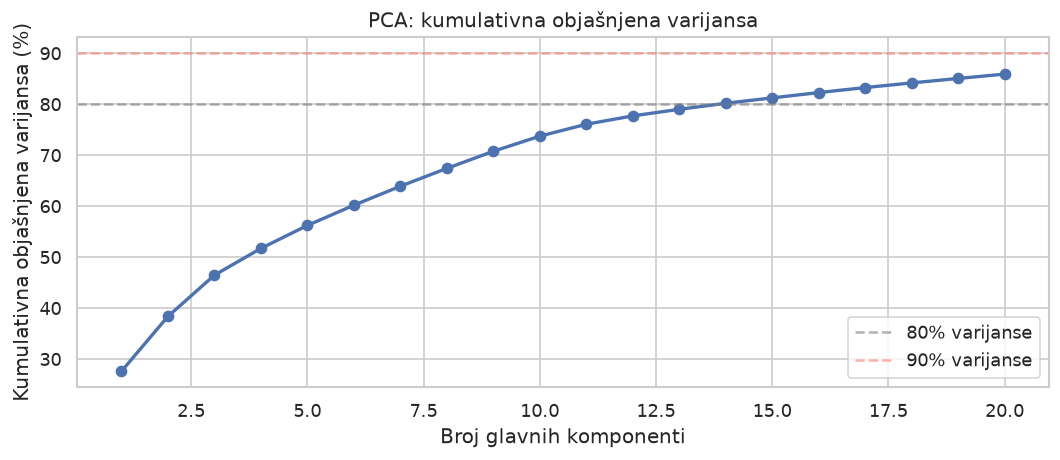

In [84]:
pca_full = PCA(n_components=20, random_state=42).fit(X_sc)
cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 21), cumulative, "o-", color=POS_COLOR, linewidth=2)
ax.axhline(80, color="gray",   linestyle="--", alpha=0.6, label="80% varijanse")
ax.axhline(90, color="salmon", linestyle="--", alpha=0.6, label="90% varijanse")
ax.set_xlabel("Broj glavnih komponenti")
ax.set_ylabel("Kumulativna objašnjena varijansa (%)")
ax.set_title("PCA: kumulativna objašnjena varijansa")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/eda/pca_varijansa.png", bbox_inches="tight")
plt.show() 
# vidimo da tek u 14-15 dimenzionom prostoru zadržavamo većinu informacija (80%)

## 10. t-SNE nelinearna vizualizacija

Nelinearna redukcija dimenzija, primenjena na prvih 50 PCA komponenti.

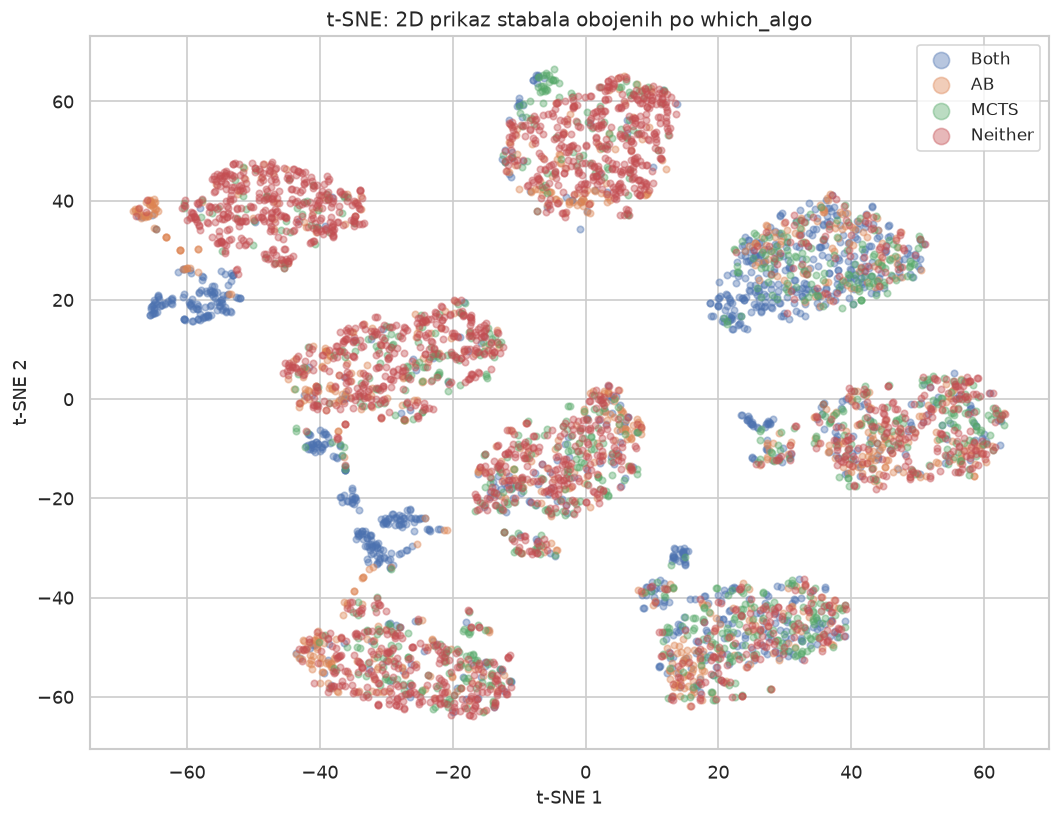

In [85]:
from sklearn.manifold import TSNE

X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_sc)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca50)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in CLASS_ORDER:
    mask = df["which_algo"] == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=CLASS_COLORS[cls], label=cls, alpha=0.4, s=15)
ax.set_xlabel("t-SNE 1", fontsize=11)
ax.set_ylabel("t-SNE 2", fontsize=11)
ax.set_title("t-SNE: 2D prikaz stabala obojenih po which_algo", fontsize=12)
ax.legend(markerscale=2.5, fontsize=10)
plt.tight_layout()
plt.savefig("../plots/eda/tsne.png", bbox_inches="tight")
plt.show()
# vidimo da klasteri postoje, međutim uglavnom pomešanih klasa pa klasifikacija neće biti jednostavna